# pytae Visualization with `Plotter` & `pt.plot`

`Plotter` is `pytae`'s method-chainable visualization engine built on top of Matplotlib and `pandas.plot()`. It eliminates visualization boilerplate by providing:
- **Single Subplot by Default**: Omit `mosaic` for single charts where `on=` is optional
- **Subplots Without Mosaic**: Use standard `nrows` and `ncols` (e.g. `pt.Plotter(df, nrows=1, ncols=2)`)
- **Direct Accessor & Functional Chaining**: `df.pt.plot(...)` and `pt.plot(df, ...)`
- **Automatic Grouped Aggregation**: Built-in `by=`, `aggfunc=`, and `palette=`
- **True Distribution Semantics**: Unaggregated `box` plots alongside `kde` and `hist`
- **Secondary Y-Axis Overlays**: Effortless dual axes via `on="A^"` syntax
- **Multi-Panel Mosaic Dashboards**: Arbitrary subplot grids using ASCII string diagrams
- **Automated Grid Faceting**: Small multiples via `pt.Plotter.facet(...)` with shared axis scales
- **Jupyter Auto-Display**: Direct inline rendering via `_repr_png_()` without requiring `p.fig`


In [1]:
import numpy as np
import pandas as pd
import pytae as pt

# Pre-load sample datasets for all cells
tips = pt.sample("tips")
penguins = pt.sample("penguins")
diamonds = pt.sample("diamonds")
titanic = pt.sample("titanic")


## 1. Single Subplots & The Three Entry Points (Default: No Mosaic Needed)

When `mosaic` is omitted, `Plotter` automatically creates a **single subplot** (axis `"A"`), and specifying `on="A"` is completely optional.

`pytae` provides three interchangeable entry points depending on your workflow:
1. **DataFrame Accessor (`df.pt.plot(...)` & `.pt.finalize()`)**: Plugs directly into pandas / pytae transformation chains with consistent `.pt` namespace throughout.
2. **Functional Style (`pt.plot(df, ...)` & `pt.finalize()`)**: Concise standalone functions for procedural workflows.
3. **Class Constructor (`pt.Plotter(df)`)**: Object-oriented single-subplot initialization with `.finalize()`.


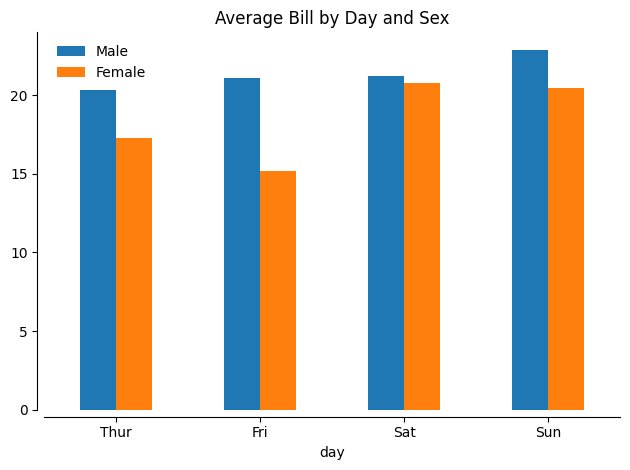

In [2]:
tips = pt.sample("tips")

# 1.1 DataFrame Accessor: single subplot without mosaic, chained directly from wrangling
(
    tips
    .pt.qry("total_bill > 10")
    .pt.plot(
        kind="bar",
        x="day",
        y="total_bill",
        by="sex",
        aggfunc="mean",
        palette="tab10",
        title="Average Bill by Day and Sex"
    )
    .pt.finalize()
)


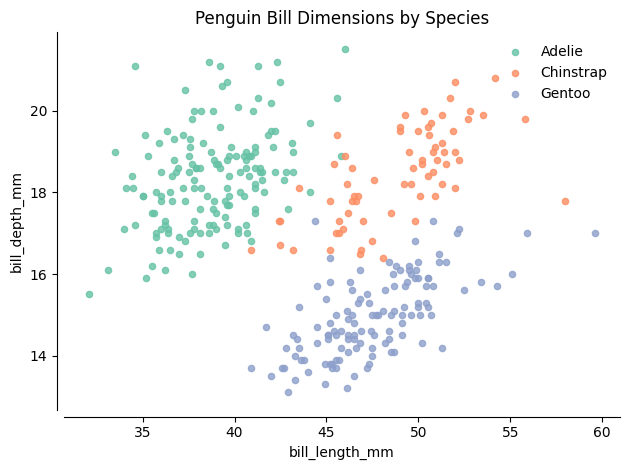

In [3]:
penguins = pt.sample("penguins")

# 1.2 Functional Style: pt.plot(...) paired with pt.finalize()
p = pt.plot(
    penguins,
    kind="scatter",
    x="bill_length_mm",
    y="bill_depth_mm",
    by="species",
    palette="Set2",
    title="Penguin Bill Dimensions by Species"
)
pt.finalize(p)


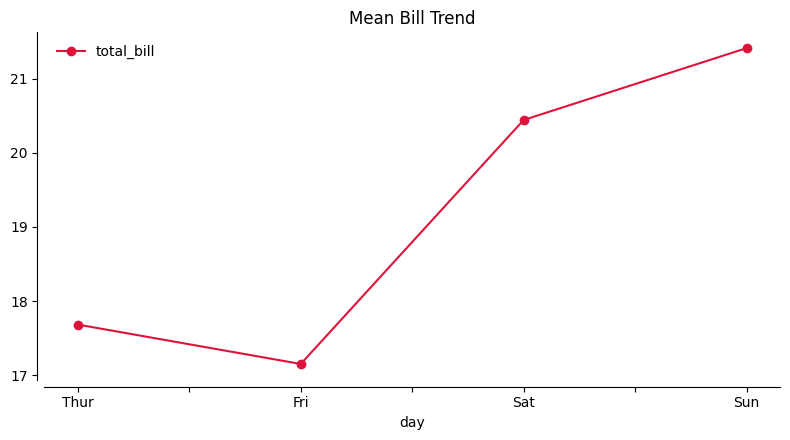

In [4]:
# 1.3 Class Constructor: pt.Plotter(df) on a single subplot (no mosaic needed)
p = pt.Plotter(tips, figsize=(8, 4.5))
(
    p
    .plot(kind="line", x="day", y="total_bill", aggfunc="mean", marker="o", color="crimson", title="Mean Bill Trend")
    .finalize()
)


## 2. Plot Kinds & Distribution Semantics

`pytae` supports a complete collection of plot kinds:
- **Aggregated / Categorical**: `bar`, `barh`, `line`, `pie`
- **Distributions**: `box` (unaggregated), `hist`, `kde` / `density`
- **Relationships**: `scatter`, `hexbin`
- **2D Matrices**: `heatmap`


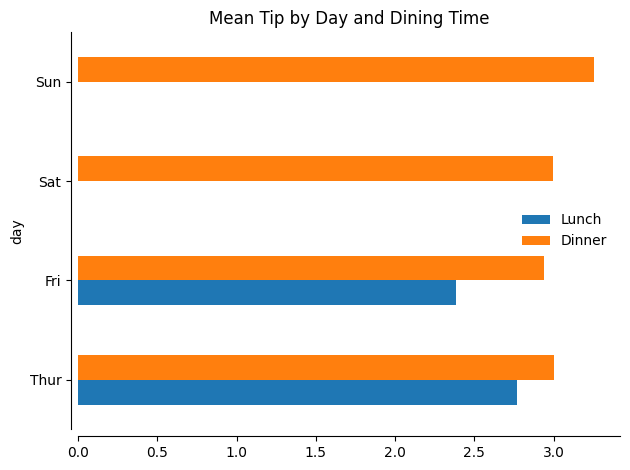

In [5]:
# 2.1 Grouped horizontal bar chart with custom aggregation
(
    tips
    .pt.plot(
        kind="barh",
        x="day",
        y="tip",
        by="time",
        aggfunc="mean",
        palette="tab10",
        title="Mean Tip by Day and Dining Time"
    )
    .pt.finalize()
)


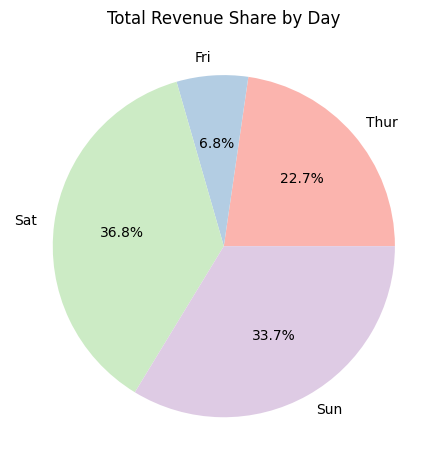

In [6]:
# 2.2 Auto-aggregated pie chart with formatted percentages
(
    tips
    .pt.plot(
        kind="pie",
        y="total_bill",
        by="day",
        aggfunc="sum",
        autopct="%1.1f%%",
        palette="Pastel1",
        title="Total Revenue Share by Day"
    )
    .pt.finalize()
)


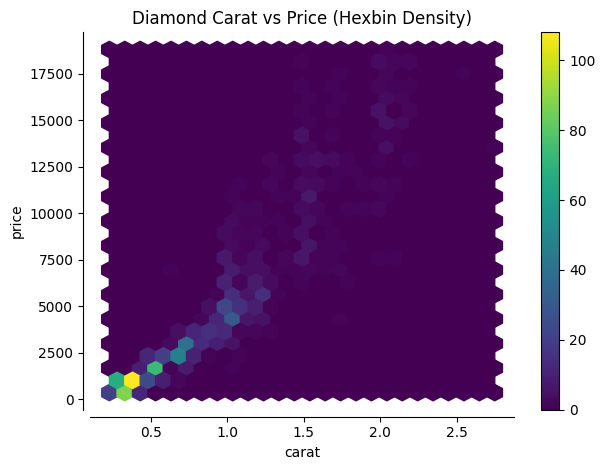

In [7]:
diamonds = pt.sample("diamonds").sample(1000, random_state=42)

# 2.3 Hexbin density plot for dense continuous distributions
(
    diamonds
    .pt.plot(
        kind="hexbin",
        x="carat",
        y="price",
        gridsize=25,
        cmap="viridis",
        title="Diamond Carat vs Price (Hexbin Density)"
    )
    .pt.finalize()
)


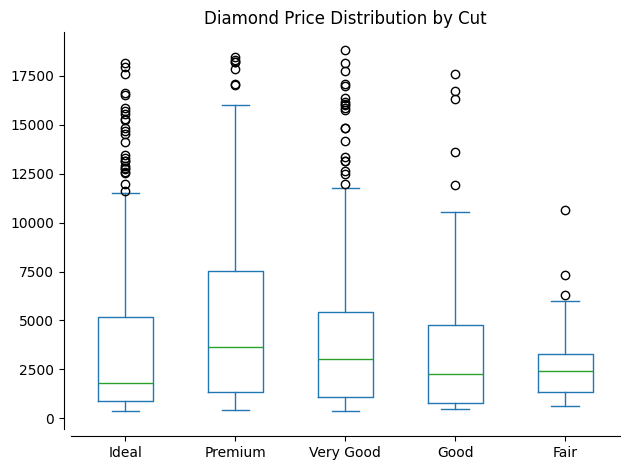

In [8]:
# 2.4 Unaggregated Box Plot: shows real distribution quartiles across categories
(
    diamonds
    .pt.plot(
        kind="box",
        x="cut",
        y="price",
        title="Diamond Price Distribution by Cut"
    )
    .pt.finalize()
)


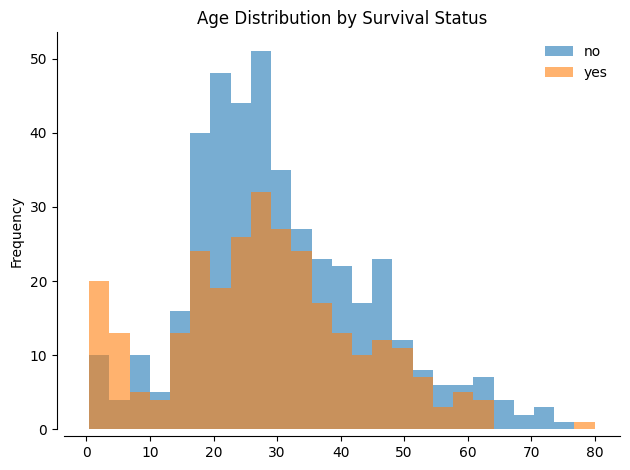

In [9]:
titanic = pt.sample("titanic")

# 2.5 Overlapping histograms split by group (accepts x= or column=)
(
    titanic
    .pt.plot(
        kind="hist",
        x="age",
        by="alive",
        bins=25,
        alpha=0.6,
        palette="tab10",
        title="Age Distribution by Survival Status"
    )
    .pt.finalize()
)


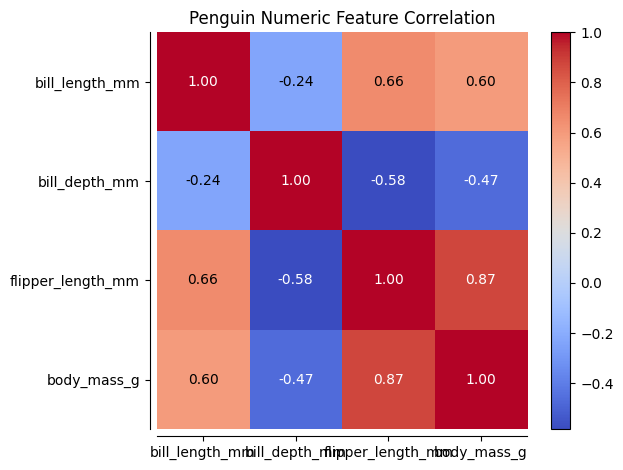

In [10]:
# 2.6 2D Heatmap: correlation matrix with numeric cell text annotations
corr = penguins.select_dtypes("number").corr()

pt.plot(
    corr,
    kind="heatmap",
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    title="Penguin Numeric Feature Correlation"
).finalize()


## 3. Subplots & Multi-Panel Dashboards (With & Without Mosaic)

You can build subplots in two ways:
1. **Without Mosaic**: Using familiar `nrows` and `ncols` (e.g. `pt.Plotter(df, nrows=1, ncols=2)`), automatically assigning panels `'A'`, `'B'`, etc.
2. **With Mosaic**: Using ASCII diagrams (`mosaic="""AB\nCD"""`) for arbitrary grid layouts.

Additionally, append `^` to an axis identifier (e.g. `on="A^"`) to overlay an independent secondary Y-axis sharing the same X-axis.


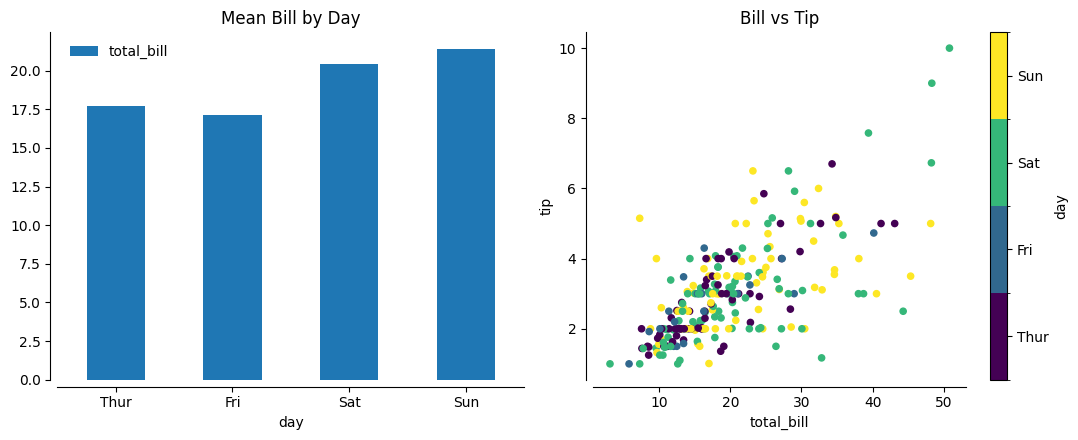

In [11]:
# 3.1 Subplots WITHOUT Mosaic: use standard nrows and ncols
p_sub = pt.Plotter(tips, nrows=1, ncols=2, figsize=(11, 4.5))
(
    p_sub
    .plot(on="A", kind="bar", x="day", y="total_bill", aggfunc="mean", palette="tab10", title="Mean Bill by Day")
    .plot(on="B", kind="scatter", x="total_bill", y="tip", c="day", cmap="viridis", title="Bill vs Tip")
    .finalize()
)


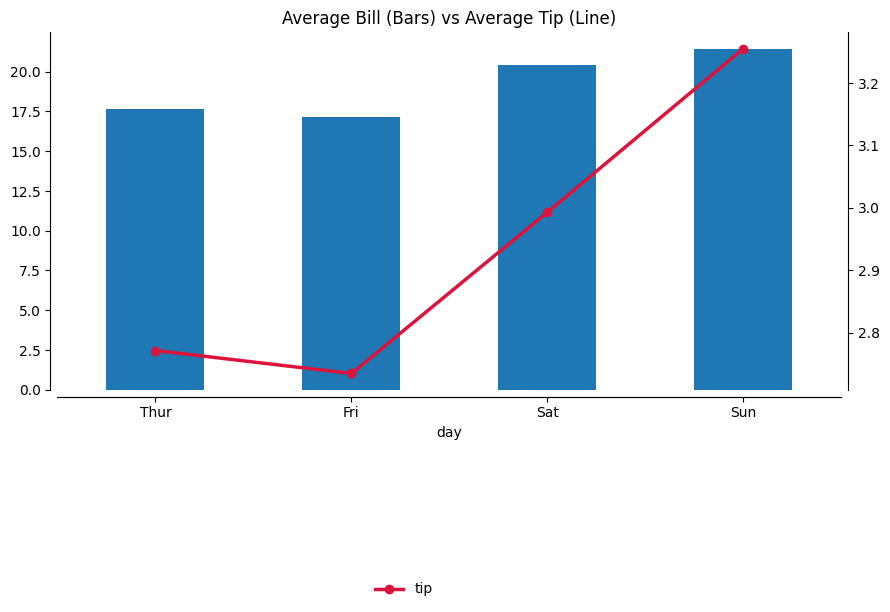

In [12]:
# 3.2 Dual-axis overlay: average bill (bar) vs average tip (line on A^)
k = pt.Plotter(tips, figsize=(9, 5))
(
    k
    .plot(on="A", kind="bar", x="day", y="total_bill", aggfunc="mean", legend=False, title="Average Bill (Bars) vs Average Tip (Line)")
    .plot(on="A^", kind="line", x="day", y="tip", aggfunc="mean", color="crimson", marker="o", linewidth=2.5)
    .finalize(consolidate_legends=True, bbox_to_anchor=(0.5, -0.15), ncols=2)
)


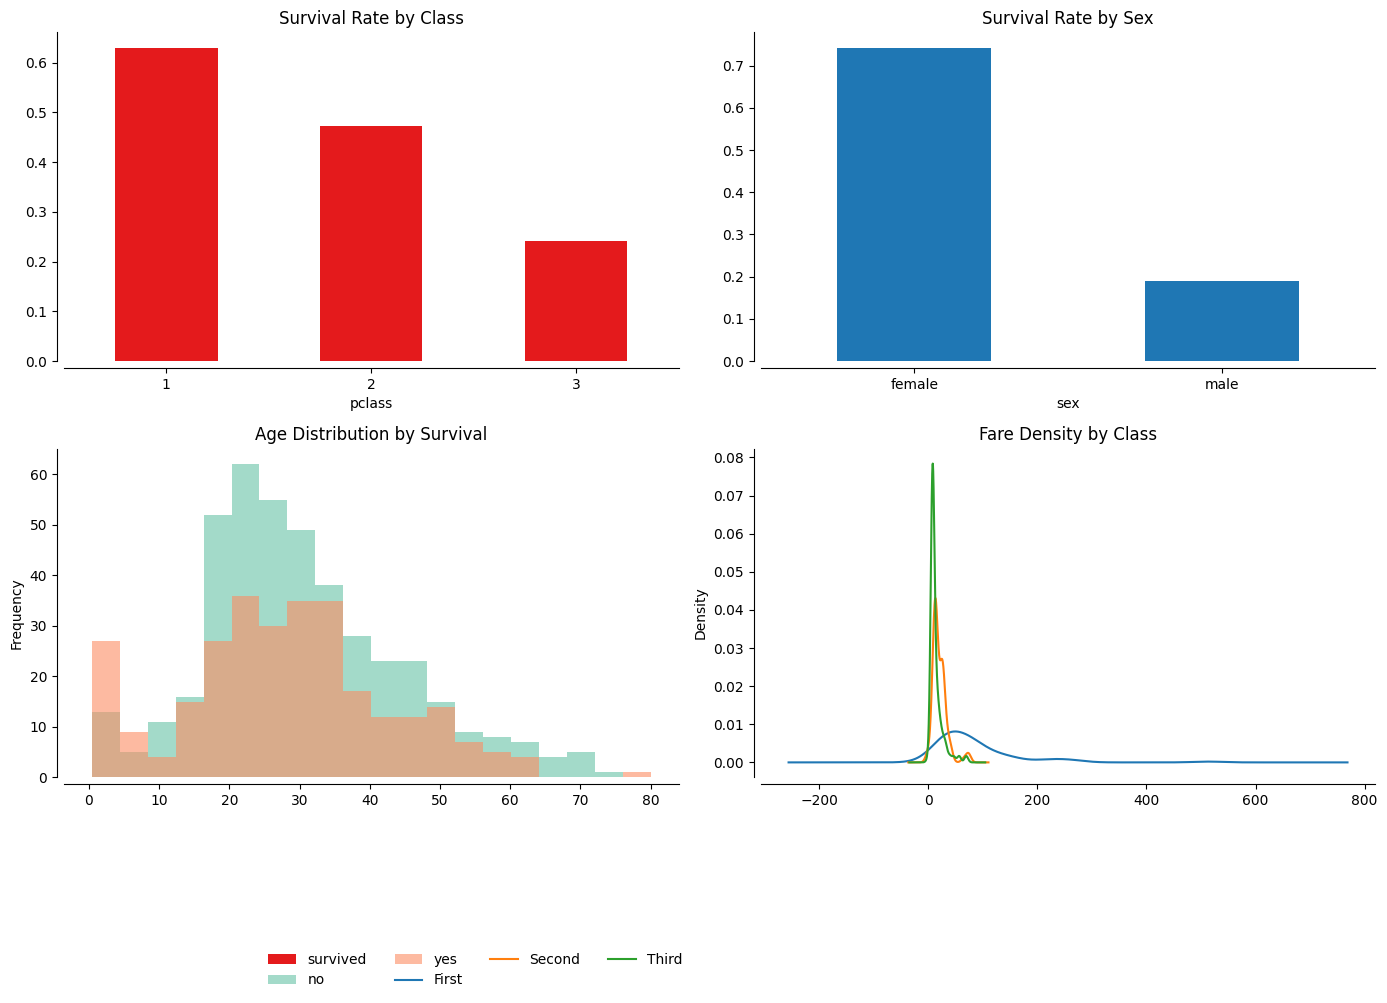

In [13]:
# 3.3 Multi-Panel Mosaic Dashboard using ASCII layout
mosaic = """
AB
CD
"""

p = pt.Plotter(titanic, mosaic=mosaic, figsize=(14, 9))
(
    p
    .plot(on="A", kind="bar", x="pclass", y="survived", aggfunc="mean", palette="Set1", title="Survival Rate by Class")
    .plot(on="B", kind="bar", x="sex", y="survived", aggfunc="mean", palette="tab10", title="Survival Rate by Sex")
    .plot(on="C", kind="hist", x="age", by="alive", bins=20, alpha=0.6, palette="Set2", title="Age Distribution by Survival")
    .plot(on="D", kind="kde", x="fare", by="class", title="Fare Density by Class")
    .finalize(consolidate_legends=True, bbox_to_anchor=(0.5, -0.05), ncols=4)
)


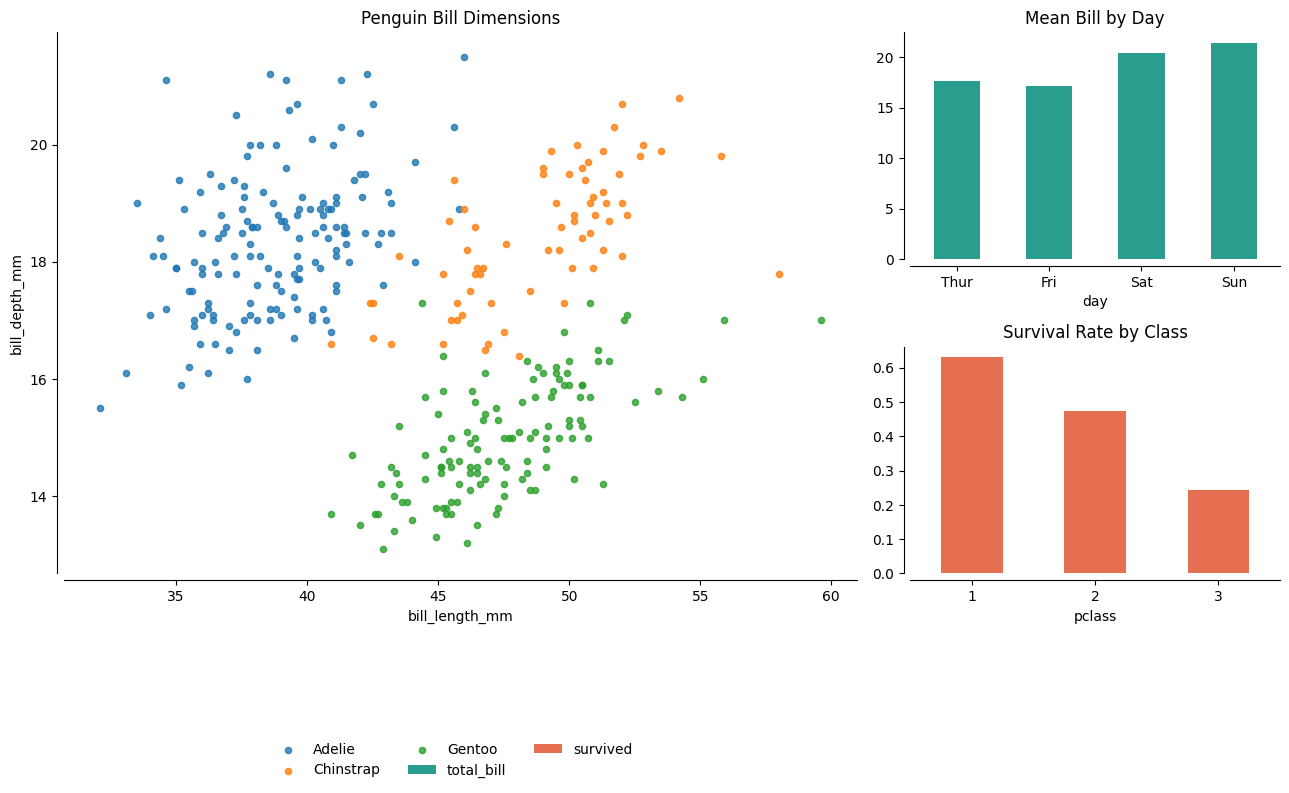

In [14]:
# 3.4 Multi-Dataset Dashboard: mix different DataFrames across panels
mosaic_multi = """
AAB
AAC
"""

p_multi = pt.Plotter(mosaic=mosaic_multi, figsize=(13, 7))
(
    p_multi
    # Panel A: Penguins scatter
    .data(penguins)
    .plot(on="A", kind="scatter", x="bill_length_mm", y="bill_depth_mm", by="species", palette="tab10", title="Penguin Bill Dimensions")
    # Panel B: Tips bar chart
    .data(tips)
    .plot(on="B", kind="bar", x="day", y="total_bill", aggfunc="mean", color="#2a9d8f", title="Mean Bill by Day")
    # Panel C: Titanic survival rate
    .data(titanic)
    .plot(on="C", kind="bar", x="pclass", y="survived", aggfunc="mean", color="#e76f51", title="Survival Rate by Class")
    .finalize(consolidate_legends=True, bbox_to_anchor=(0.5, -0.05), ncols=3)
)


## 4. Grid Faceting / Small Multiples (Auto-Faceting with `by` & `ncols`)

Split a dataset across an automated grid of subplots for each distinct level of a categorical column.

`pytae` automatically recognizes faceting whenever `by=` and `ncols=` are passed to **`pt.plot(...)`**, **`df.pt.plot(...)`**, or **`pt.Plotter(...)`**—no need to remember a separate `pt.Plotter.facet` class method! (The explicit `pt.Plotter.facet` is still fully supported as an alias). Leftover grid cells are automatically kept clean.


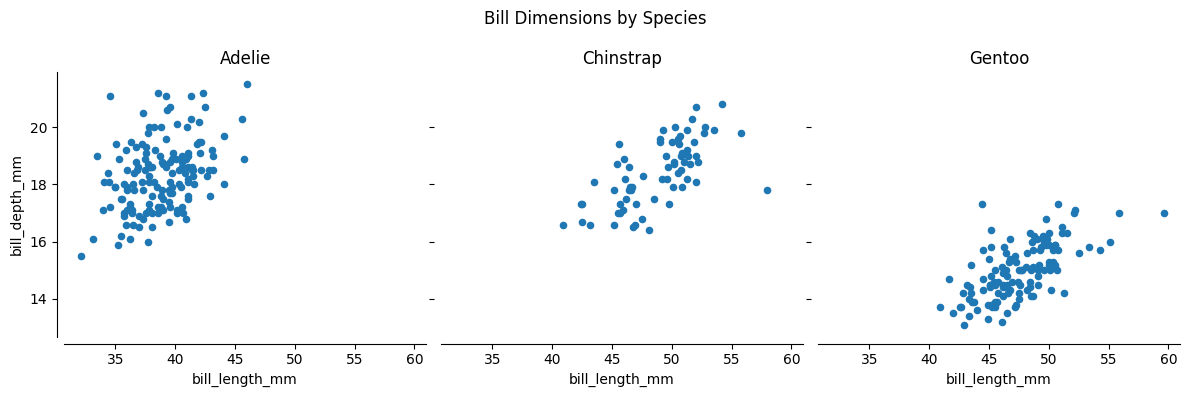

In [15]:
# 4.1 Auto-Faceting with pt.plot(by="species", ncols=3): automatic small multiples grid
pt.plot(
    penguins,
    by="species",
    ncols=3,
    x="bill_length_mm",
    y="bill_depth_mm",
    kind="scatter",
    sharex=True,
    sharey=True,
    figsize=(12, 4),
    title="Bill Dimensions by Species"
).finalize()


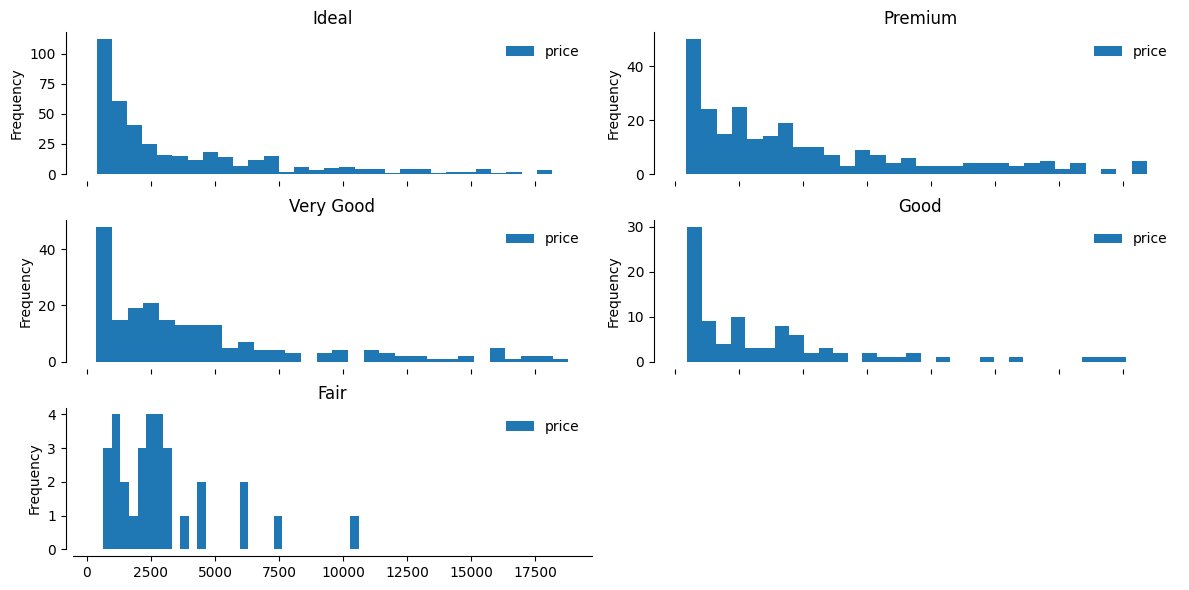

In [29]:
# 4.2 Fluent Accessor Auto-Faceting: df.pt.plot(by="cut", ncols=3)
(
    diamonds
    .pt.plot(
        by="cut",
        ncols=2,
        x="price",
        kind="hist",
        bins=30,
        figsize=(12, 6),
        titles=True,
        sharex=True
    )
    .pt.finalize()
)


## 5. End-to-End Pipelines: Mixing pandas, pytae, and Multi-Panel Mosaics

Because `pytae` methods return standard pandas DataFrames, you can freely mix standard pandas operations (`.dropna()`, `.rename()`, `.sort_values()`, `.query()`) with `pytae` verbs (`.pt.mutate()`, `.pt.qry()`, `.pt.select()`) in a single chained pipeline that ends directly in a multi-panel mosaic dashboard.


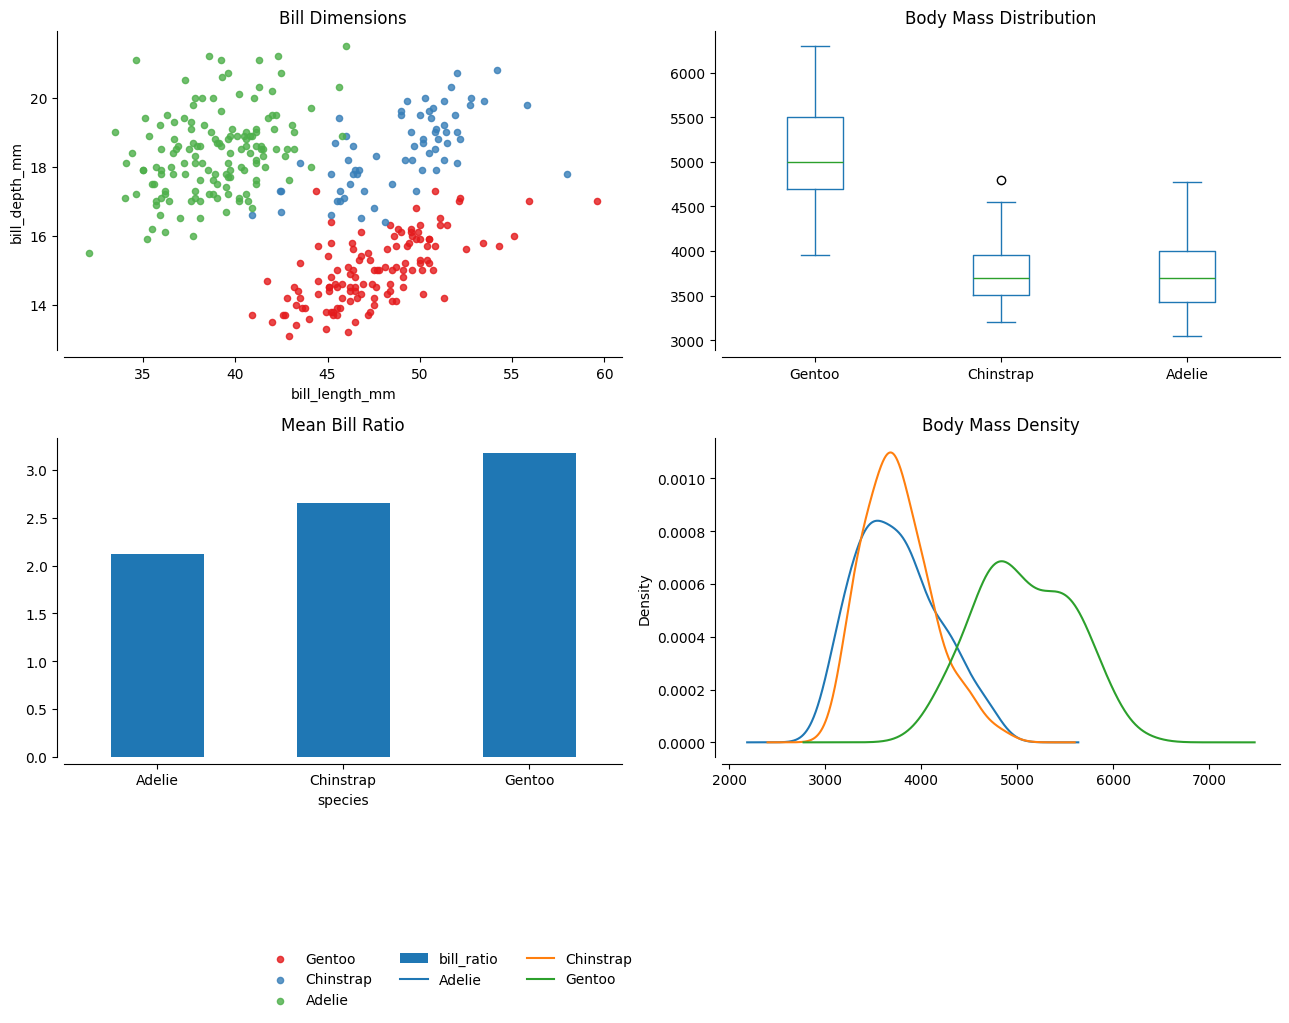

In [17]:
# 5.1 Continuous Accessor Chain: pandas + pytae + mosaic dashboard
(
    penguins
    # 1. pandas: Drop missing measurements
    .dropna(subset=["bill_length_mm", "bill_depth_mm", "body_mass_g"])
    # 2. pytae: Feature engineering (compute ratio and scaled mass)
    .pt.mutate(bill_ratio="bill_length_mm / bill_depth_mm", mass_kg="body_mass_g / 1000")
    # 3. pytae: Expressive filter
    .pt.qry("mass_kg > 3.0")
    # 4. pandas: Sort observations
    .sort_values("body_mass_g", ascending=False)
    # 5. pytae: Launch mosaic dashboard directly
    .pt.plot(
        mosaic="""
        AB
        CD
        """,
        figsize=(13, 9)
    )
    .plot(on="A", kind="scatter", x="bill_length_mm", y="bill_depth_mm", by="species", palette="Set1", title="Bill Dimensions")
    .plot(on="B", kind="box", x="species", y="body_mass_g", title="Body Mass Distribution")
    .plot(on="C", kind="bar", x="species", y="bill_ratio", aggfunc="mean", palette="tab10", title="Mean Bill Ratio")
    .plot(on="D", kind="kde", x="body_mass_g", by="species", title="Body Mass Density")
    .pt.finalize(consolidate_legends=True, bbox_to_anchor=(0.5, -0.05), ncols=3)
)


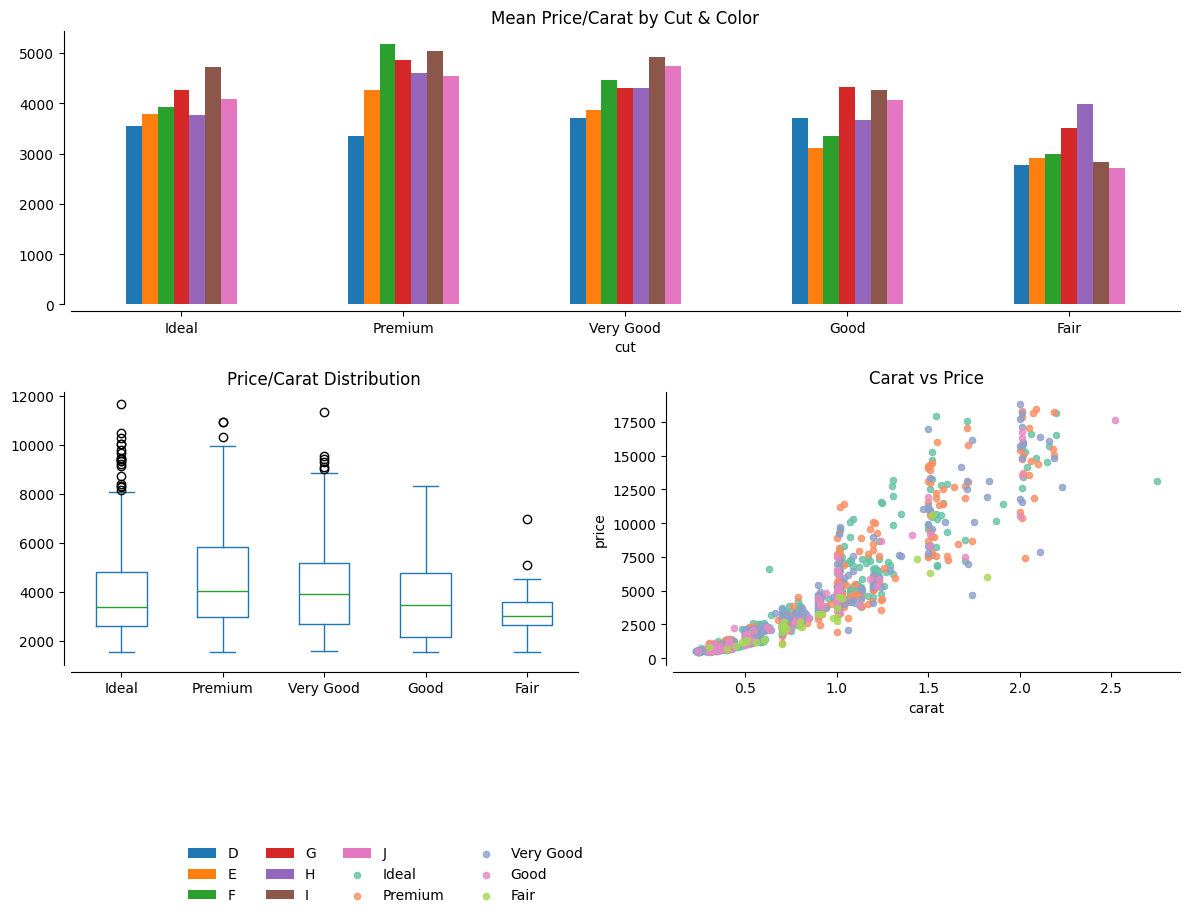

In [18]:
# 5.2 Functional Style: wrangle with mixed verbs, then pass to pt.plot(mosaic=...)
cleaned_diamonds = (
    diamonds
    .rename(columns={"table": "table_pct"})
    .pt.select("cut", "color", "price", "carat")
    .pt.mutate(price_per_carat="price / carat")
    .query("price_per_carat > 1500")
)

(
    pt.plot(
        cleaned_diamonds,
        mosaic="""
        AA
        BC
        """,
        figsize=(12, 8)
    )
    .plot(on="A", kind="bar", x="cut", y="price_per_carat", by="color", aggfunc="mean", palette="tab10", title="Mean Price/Carat by Cut & Color")
    .plot(on="B", kind="box", x="cut", y="price_per_carat", title="Price/Carat Distribution")
    .plot(on="C", kind="scatter", x="carat", y="price", by="cut", palette="Set2", title="Carat vs Price")
    .finalize(consolidate_legends=True, bbox_to_anchor=(0.5, -0.05), ncols=4)
)


## 6. Advanced Controls & Customization (`_CONTROL_KWARGS`)

`pytae` provides 10 dedicated control kwargs that drive `Plotter` behavior directly and are handled before delegating to Matplotlib:

| Control Kwarg | Type / Values | Purpose |
|---|---|---|
| `on` | `str` (`"A"`, `"B"`, `"A^"`) | Routes plot to a specific mosaic panel or secondary axis |
| `print_data` | `bool` | Prints the post-aggregated / pivoted DataFrame to stdout |
| `clip_data` | `bool` | Copies the post-aggregated DataFrame to system clipboard |
| `secondary_y` | `bool` | Routes to secondary Y-axis (equivalent to `on="A^"`) |
| `aggregate` | `bool` (default `True`) | Controls pre-aggregation; set `False` for wide/raw data |
| `xlabel` | `str` | Custom X-axis label override |
| `ylabel` | `str` | Custom Y-axis label override |
| `palette` | `str` (e.g. `"tab10"`, `"Set2"`) | Built-in colormap for discrete categories |
| `annot` | `bool` | Annotates heatmap cells with numeric values (see 2.6) |
| `fmt` | `str` (e.g. `".2f"`, `".1f"`) | Format string specifier for heatmap annotations (see 2.6) |


In [19]:
# 6.1 Control Kwargs: print_data, clip_data, xlabel, and ylabel
p = (
    tips
    .pt.plot(
        kind="bar",
        x="day",
        y="total_bill",
        by="sex",
        aggfunc="mean",
        palette="tab10",
        xlabel="Day of Week",
        ylabel="Average Total Bill ($)",
        title="Average Bill by Day and Sex",
        print_data=True,  # Prints the exact aggregated DataFrame sent to Matplotlib
        clip_data=True    # Copies the aggregated DataFrame to system clipboard for pasting
    )
    .pt.finalize()
)

# You can also retrieve the plotted DataFrame anytime via p.get_data("A")
print("\nRetrieved via p.get_data('A'):")
print(p.get_data("A"))


    day       Male     Female
0  Thur  18.714667  16.715312
1   Fri  19.857000  14.145556
2   Sat  20.802542  19.680357
3   Sun  21.887241  19.872222

Retrieved via p.get_data('A'):
    day       Male     Female
0  Thur  18.714667  16.715312
1   Fri  19.857000  14.145556
2   Sat  20.802542  19.680357
3   Sun  21.887241  19.872222


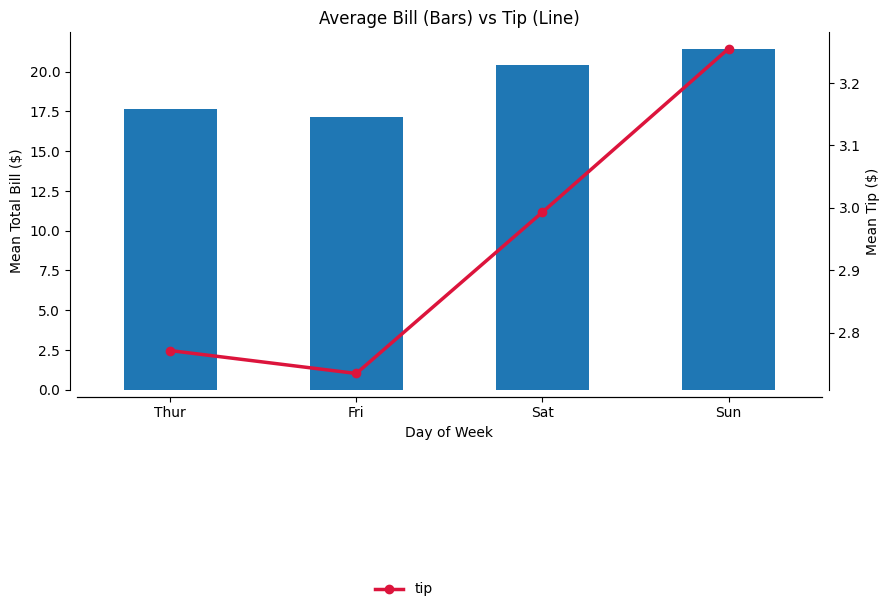

In [20]:
# 6.2 Control Kwarg: secondary_y=True for automatic secondary Y-axis routing
k = pt.Plotter(tips, figsize=(9, 5))
(
    k
    .plot(on="A", kind="bar", x="day", y="total_bill", aggfunc="mean", legend=False,
          xlabel="Day of Week", ylabel="Mean Total Bill ($)", title="Average Bill (Bars) vs Tip (Line)")
    .plot(kind="line", x="day", y="tip", aggfunc="mean", secondary_y=True,
          color="crimson", marker="o", linewidth=2.5, ylabel="Mean Tip ($)")
    .finalize(consolidate_legends=True, bbox_to_anchor=(0.5, -0.15), ncols=2)
)
k.fig


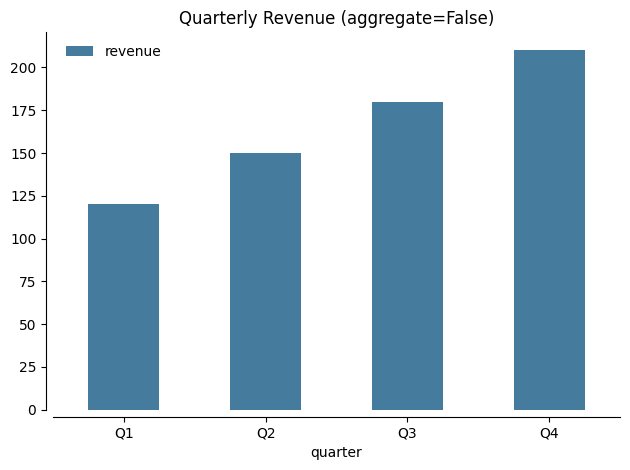

In [21]:
# 6.3 Control Kwarg: aggregate=False (Wide-Format Pre-Aggregated Data)
pre_aggregated = pd.DataFrame({
    "quarter": ["Q1", "Q2", "Q3", "Q4"],
    "revenue": [120, 150, 180, 210]
})

(
    pre_aggregated
    .pt.plot(kind="bar", x="quarter", y="revenue", aggregate=False, color="#457b9d", title="Quarterly Revenue (aggregate=False)")
    .pt.finalize()
)


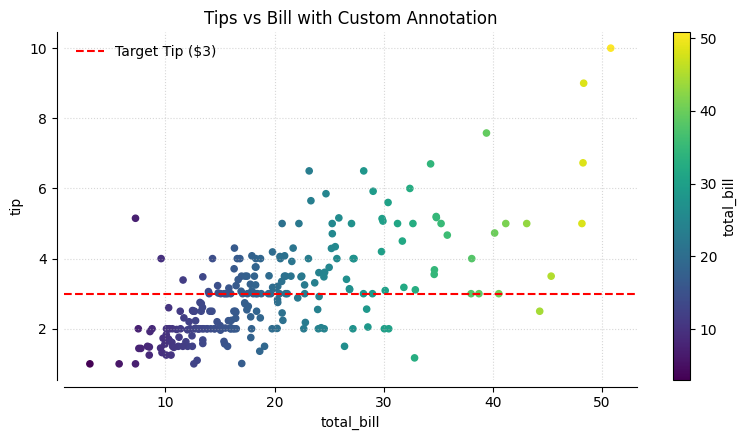

In [22]:
# 6.4 Direct Matplotlib Styling (axd, fig) and Figure Export
k = pt.Plotter(tips, figsize=(8, 4.5))
(
    k
    .plot(kind="scatter", x="total_bill", y="tip", c="total_bill", cmap="viridis", title="Tips vs Bill with Custom Annotation")
)

# Access raw Matplotlib Axes directly before finalization
k.axd["A"].axhline(3.0, color="red", linestyle="--", linewidth=1.5, label=r"Target Tip (\$3)")
k.axd["A"].grid(True, linestyle=":", alpha=0.5)

# Finalize the figure (export anytime via: k.save("chart.png", dpi=150))
k.finalize()
k.fig


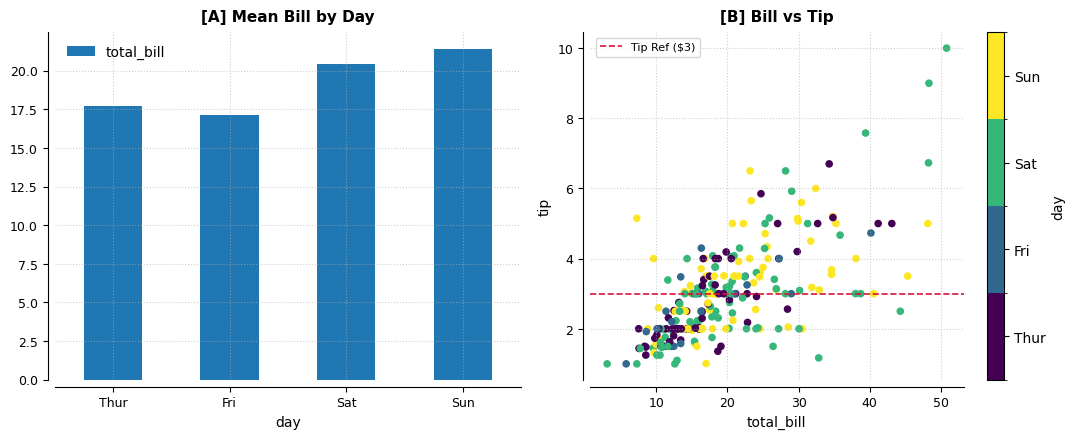

In [23]:
# 6.5 Post-Plot Manipulation: Iterating over Subplots in a for loop via p.axd
p = pt.Plotter(tips, nrows=1, ncols=2, figsize=(11, 4.5))
(
    p
    .plot(on="A", kind="bar", x="day", y="total_bill", aggfunc="mean", palette="tab10", title="Mean Bill by Day")
    .plot(on="B", kind="scatter", x="total_bill", y="tip", c="day", cmap="viridis", title="Bill vs Tip")
    .finalize()
)

# Loop over all subplots via p.axd for fine-grained Matplotlib controls
for key, ax in p.axd.items():
    # 1. Add subtle custom grid lines
    ax.grid(True, linestyle=":", alpha=0.6)
    # 2. Add panel badge to title
    ax.set_title(f"[{key}] {ax.get_title()}", fontsize=11, fontweight="bold", pad=8)
    # 3. Fine-tune tick label font sizes
    ax.tick_params(axis="both", labelsize=9)

# Specific override on panel B
p.axd["B"].axhline(3.0, color="crimson", linestyle="--", linewidth=1.2, label=r"Tip Ref (\$3)")
p.axd["B"].legend(loc="upper left", frameon=True, fontsize=8)

p.fig


In [24]:
# 6.6 Introspect which kwargs are unsupported vs pytae controls (_CONTROL_KWARGS)
for plot_kind in ["scatter", "bar", "box", "hist"]:
    info = pt.Plotter.supported_kwargs(plot_kind)
    print(f"kind='{plot_kind}': unsupported={info['unsupported']}, controls={info['pytae_controls']}")


kind='scatter': unsupported=['aggfunc', 'dropna'], controls=['aggregate', 'annot', 'clip_data', 'fmt', 'on', 'palette', 'print_data', 'secondary_y', 'xlabel', 'ylabel']
kind='bar': unsupported=[], controls=['aggfunc', 'aggregate', 'annot', 'by', 'clip_data', 'dropna', 'fmt', 'on', 'palette', 'print_data', 'secondary_y', 'xlabel', 'y', 'ylabel']
kind='box': unsupported=['aggfunc', 'dropna'], controls=['aggregate', 'annot', 'by', 'clip_data', 'column', 'fmt', 'on', 'palette', 'print_data', 'secondary_y', 'x', 'xlabel', 'y', 'ylabel']
kind='hist': unsupported=['aggfunc', 'dropna'], controls=['aggregate', 'annot', 'by', 'clip_data', 'column', 'fmt', 'on', 'palette', 'print_data', 'secondary_y', 'x', 'xlabel', 'y', 'ylabel']
